# Setup

In [35]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [36]:
pd.options.display.float_format = '{:.2f}'.format

In [37]:
KAGGLE_DIR = Path('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1')
IS_KAGGLE = KAGGLE_DIR.exists()

DATA_DIR = KAGGLE_DIR if IS_KAGGLE else Path('./data')
IMG_DIR = DATA_DIR / 'images'
DEBUG = not IS_KAGGLE
NUM_WORKERS = 2 if IS_KAGGLE else 0

print(f'{IS_KAGGLE=}')
print(f'{DEBUG=}')
print(f'{DATA_DIR=}')
print(f'{IMG_DIR=}')

IS_KAGGLE=False
DEBUG=True
DATA_DIR=WindowsPath('data')
IMG_DIR=WindowsPath('data/images')


Data loading

In [38]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(train_df.shape)
print(test_df.shape)

train_df.head(3)

(51043, 21)
(17015, 1)


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
files_req = set(train_df['id']) | set(test_df['id'])
files_img_dir = set(p.name for p in IMG_DIR.glob('*.png'))

if len(files_req - files_img_dir) == 0:
  print('All files are present ✅')

All files are present ✅


# Exploratory data analysis

Looking at first image

Size (W, H): (384, 384)
Mode: RGB
Image as np.array (H, W, C): (384, 384, 3)


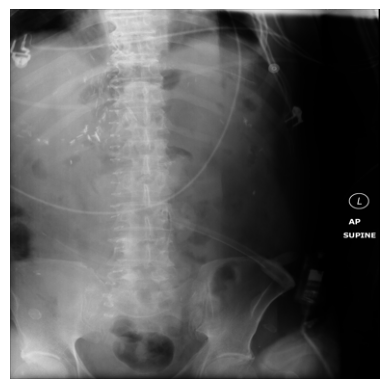

In [40]:
img_path = IMG_DIR / train_df.loc[0, 'id']
img = Image.open(img_path)
img_arr = np.array(img)

print(f'Size (W, H): {img.size}')
print(f'Mode: {img.mode}')
print(f'Image as np.array (H, W, C): {img_arr.shape}')

_ = plt.imshow(img)
_ = plt.axis('off')

Check if all channels are identical

The image is actually grayscale. Does the same grayscale values repeated across all channels?

In [41]:
r = img_arr[:, :, 0]
g = img_arr[:, :, 1]
b = img_arr[:, :, 2]

np.array_equal(r, g) and np.array_equal(g, b)

True

Looking at all disease classes

In [42]:
disease_classes = list(train_df.columns[1:])
print(len(disease_classes))
print(disease_classes)

20
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


How many samples per class in our train data?

In [43]:
class_counts = train_df[disease_classes].sum(axis=0)
class_counts = class_counts.sort_values(ascending=False)
class_counts_pct = class_counts / len(train_df) * 100

pd.DataFrame({
    'Count': class_counts,
    '%': class_counts_pct
})

,Count,%
No Finding,34079,66.77
Infiltration,5206,10.20
Atelectasis,2351,4.61
Effusion,2156,4.22
Nodule,1527,2.99
Mass,1249,2.45
Pneumothorax,1114,2.18
Consolidation,651,1.28
Pleural_Thickening,608,1.19
Cardiomegaly,600,1.18


Distribution of diseases is very imbalanced and we need take care of it during model training and evaluation.

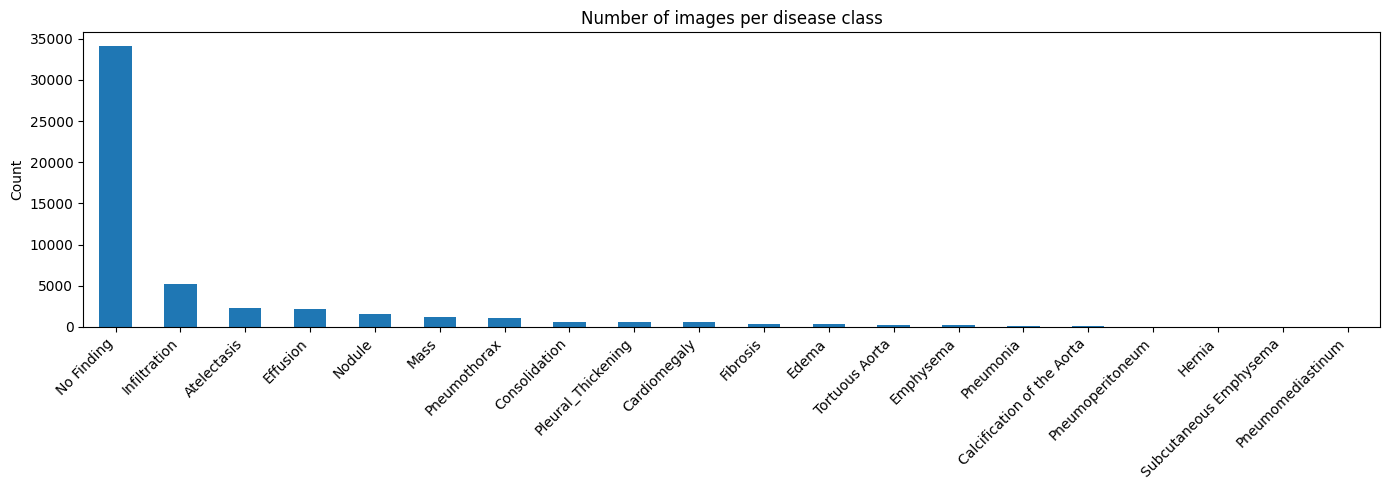

In [44]:
_ = plt.figure(figsize=(14, 5))
_ = class_counts.plot(kind='bar')
_ = plt.title('Number of images per disease class')
_ = plt.ylabel('Count')
_ = plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Dataset & DataLoader

In [45]:
# Training: add some random flips/rotations to help the model generalize
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),        # resize to standard size
    transforms.RandomHorizontalFlip(),    # randomly flip left-right
    transforms.RandomRotation(10),        # randomly rotate ±10 degrees
    transforms.ToTensor(),                # convert image to numbers
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # standard ImageNet normalization
])

# Validation/Test: no random augmentation, just resize and normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [46]:
class ChestXrayDataset(Dataset):
  def __init__(self, dataframe, img_dir, transform):
    self.df = dataframe.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform
    self.disease_classes = dataframe.columns[1:].tolist()

  def __len__(self):
    # how many images total
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = self.img_dir / row.iloc[0]

    # open the image
    img = Image.open(img_path).convert('RGB')
    img = self.transform(img)

    # find which column has the "1" → that's the label
    label_values = row[self.disease_classes].values.astype(float)
    label = torch.tensor(label_values).argmax().long()

    return img, label

Split data into train and validation sets

In [47]:
# Get class index for each image (used for stratified split)
label_indices = train_df[disease_classes].values.argmax(axis=1)

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=label_indices  # keep class ratios same in both splits
)

print("Train size:", len(train_split_df))
print("Val size:  ", len(val_split_df))

Train size: 40834
Val size:   10209


In [48]:
train_dataset = ChestXrayDataset(train_split_df, IMG_DIR, train_transform)
val_dataset = ChestXrayDataset(val_split_df, IMG_DIR, val_transform)

print(f'Train Dataset: {len(train_dataset)}')
print(f'Val Dataset: {len(val_dataset)}')

Train Dataset: 40834
Val Dataset: 10209


Looking at the first sample in the train dataset

In [49]:
img, label = train_dataset[0]
print(type(img))
print(img.shape)  # (C, H, W)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
tensor(19)


In [50]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True
)

val_loader = DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Train batches: 1277
Val batches:   320


Looking at the first batch of train loader

In [51]:
features, labels = next(iter(train_loader))
print(features.shape)  # (BATCH_SIZE, C, H, W)
print(labels.shape)  # (BATCH_SIZE)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Model building

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [53]:
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

In [54]:
# Looking at the meta properties
for key, val in weights.meta.items():
  print(f'{key}: {val}')

min_size: (29, 29)
categories: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 

In [55]:
# Looking at the pre training transforms
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [56]:
# Looking at the classifier head
model.classifier

Linear(in_features=1024, out_features=1000, bias=True)

In [57]:
# Updating the classifier head
NUM_CLASSES = 20

model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES)
)

In [58]:
# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter Count:")
print(f"Total      : {total_params:,}")
print(f"Trainable  : {trainable_params:,}")

Parameter Count:
Total      : 7,488,916
Trainable  : 7,488,916


In [59]:
# Wrap model for multi-GPU after moving to device
if torch.cuda.device_count() > 1:
  print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
  model = nn.DataParallel(model)
else:
  print("Single GPU or CPU — DataParallel not applied")

model = model.to(device)

Single GPU or CPU — DataParallel not applied


# Define loss and optimizer

In [60]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Competition scoring function

In [61]:
def competition_score(true_labels, predicted_labels, num_classes=20):
  """
  TP = +1, FP = -1, FN = -5
  Returns macro-averaged score across all classes
  """
  scores = []
  for c in range(num_classes):
    tp = ((predicted_labels == c) & (true_labels == c)).sum()
    fp = ((predicted_labels == c) & (true_labels != c)).sum()
    fn = ((predicted_labels != c) & (true_labels == c)).sum()
    nc = (true_labels == c).sum()
    if nc == 0:
      continue
    score_c = (tp - fp - 5 * fn) / nc
    scores.append(score_c)
  return round(float(np.mean(scores)), 4)

# Model training and evaluation

In [67]:
# Constants
DEBUG_BATCHES = 5
TRAIN_PRINT_EVERY = 50
EVAL_PRINT_EVERY = 50
NUM_EPOCHS = 2 if DEBUG else 20
PATIENCE = 5
CHECKPOINT_PATH = Path('models/best_model.pth')

In [63]:
def train_one_epoch(model, loader, criterion, optimizer):
  model.train()
  total_loss = 0
  all_preds, all_labels = [], []

  for batch_idx, (images, labels) in enumerate(loader):
    if DEBUG and batch_idx >= DEBUG_BATCHES:
      break

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    preds = outputs.argmax(dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

    print_every = 1 if DEBUG else TRAIN_PRINT_EVERY
    if batch_idx % print_every == 0:
      print(f"  Batch {batch_idx}/{len(loader)}  loss: {loss.item():.4f}")

  num_batches = min(DEBUG_BATCHES, len(loader)) if DEBUG else len(loader)
  avg_loss = total_loss / num_batches
  return avg_loss, np.array(all_preds), np.array(all_labels)

In [64]:
def evaluate(model, loader):
  model.eval()
  all_preds, all_labels = [], []

  with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(loader):
      if DEBUG and batch_idx >= DEBUG_BATCHES:
        break

      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      preds = outputs.argmax(dim=1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

      print_every = 1 if DEBUG else EVAL_PRINT_EVERY
      if batch_idx % print_every == 0:
        print(f"  Eval batch {batch_idx}/{len(loader)}")

  return np.array(all_preds), np.array(all_labels)

In [65]:
def run_training(model, train_loader, val_loader, criterion, optimizer):
  CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

  best_val_score = float('-inf')
  epochs_without_improvement = 0

  for epoch in range(NUM_EPOCHS):
    print(f"--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    print("  [Training...]")
    train_loss, tr_preds, tr_labels = train_one_epoch(model, train_loader, criterion, optimizer)
    print("  [Training done]")

    print("  [Evaluating...]")
    val_preds, val_labels = evaluate(model, val_loader)
    print("  [Evaluation done]")

    train_score = competition_score(tr_labels, tr_preds)
    val_score = competition_score(val_labels, val_preds)
    print(f"  Train loss: {train_loss:.4f} | Train score: {train_score} | Val score: {val_score}\n")

    if val_score > best_val_score:
      best_val_score = val_score
      epochs_without_improvement = 0
      torch.save(model.state_dict(), CHECKPOINT_PATH)
      print(f"  New best val score: {best_val_score:.4f} — model saved to {CHECKPOINT_PATH}\n")
    else:
      epochs_without_improvement += 1
      print(f"  No improvement for {epochs_without_improvement}/{PATIENCE} epochs\n")
      if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

  print(f"Training complete. Best val score: {best_val_score:.4f}")

In [66]:
run_training(model, train_loader, val_loader, criterion, optimizer)

--- Epoch 1/2 ---
  [Training...]
  Batch 0/1277  loss: 3.2482
  Batch 1/1277  loss: 3.0636
  Batch 2/1277  loss: 2.9274
  Batch 3/1277  loss: 2.7244
  Batch 4/1277  loss: 2.6792
  [Training done]
  [Evaluating...]
  Eval batch 0/320
  Eval batch 1/320
  Eval batch 2/320
  Eval batch 3/320
  Eval batch 4/320
  [Evaluation done]
  Train loss: 2.9286 | Train score: -7.1357 | Val score: -4.5077

  New best val score: -4.5077 — model saved to data\models\best_model.pth

--- Epoch 2/2 ---
  [Training...]
  Batch 0/1277  loss: 2.5538
  Batch 1/1277  loss: 2.2578
  Batch 2/1277  loss: 2.0958


KeyboardInterrupt: 

In [ ]:
class ChestXrayTestDataset(Dataset):
  def __init__(self, dataframe, img_dir, transform):
    self.df = dataframe.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_id = self.df.iloc[idx, 0]
    img_path = self.img_dir / img_id
    img = Image.open(img_path).convert('RGB')
    img = self.transform(img)
    return img, img_id

In [69]:
test_dataset = ChestXrayTestDataset(test_df, IMG_DIR, val_transform)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
print(f'# Samples in test: {len(test_dataset)}')
print(f'Test batches: {len(test_loader)}')

# Samples in test: 17015
Test batches: 532


In [70]:
def generate_predictions(model, loader, disease_classes):
  model.eval()
  all_ids = []
  all_preds = []

  with torch.no_grad():
    for batch_idx, (images, img_ids) in enumerate(loader):
      images = images.to(device)
      outputs = model(images)
      preds = outputs.argmax(dim=1).cpu().numpy()

      all_ids.extend(img_ids)
      all_preds.extend(preds)

      if batch_idx % 50 == 0:
        print(f"  Batch {batch_idx}/{len(loader)}")

  # Build one-hot encoded submission rows
  rows = []
  for img_id, pred in zip(all_ids, all_preds):
    row = {'id': img_id}
    for i, cls in enumerate(disease_classes):
      row[cls] = 1 if i == pred else 0
    rows.append(row)

  submission_df = pd.DataFrame(rows)
  return submission_df